In [111]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="black">ch03. 비지도학습 군집분석</font>

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(160, 195)

162

In [4]:
data = []
for i in range(50):
    # 여자 데이터 (키와 몸무게) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터 (키와 몸무게) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [5]:
print('여자 몸무게 (x축) : ',[female[0] for female in data[::2]])
print('여자 몸무게 (y축) : ',[female[1] for female in data[::2]])

여자 몸무게 (x축) :  [58, 70, 40, 56, 44, 57, 43, 59, 44, 50, 64, 59, 46, 53, 55, 44, 60, 58, 45, 70, 46, 65, 59, 41, 42, 50, 60, 47, 53, 44, 63, 59, 59, 47, 44, 55, 44, 58, 49, 44, 62, 65, 47, 46, 68, 59, 62, 44, 52, 51]
여자 몸무게 (y축) :  [141, 146, 153, 159, 148, 168, 158, 140, 161, 159, 145, 159, 170, 147, 142, 161, 153, 149, 167, 150, 159, 144, 145, 152, 165, 140, 147, 151, 158, 164, 148, 157, 142, 142, 140, 151, 164, 150, 141, 166, 147, 164, 169, 168, 161, 160, 170, 156, 144, 160]


In [6]:
print('남자 몸무게 (x축) : ',[male[0] for male in data[1::2]])
print('남자 몸무게 (y축) : ',[male[1] for male in data[1::2]])

남자 몸무게 (x축) :  [84, 81, 87, 73, 69, 74, 66, 94, 68, 70, 79, 86, 75, 86, 82, 89, 68, 94, 84, 81, 60, 89, 62, 65, 89, 86, 72, 72, 80, 94, 78, 73, 92, 66, 91, 90, 94, 66, 88, 71, 95, 74, 67, 94, 95, 65, 80, 60, 76, 62]
남자 몸무게 (y축) :  [175, 176, 166, 177, 195, 182, 192, 172, 191, 164, 187, 178, 175, 187, 190, 167, 181, 160, 167, 176, 190, 194, 189, 165, 188, 187, 165, 172, 170, 193, 178, 171, 164, 167, 183, 160, 165, 171, 181, 187, 162, 191, 168, 179, 177, 179, 186, 166, 171, 177]


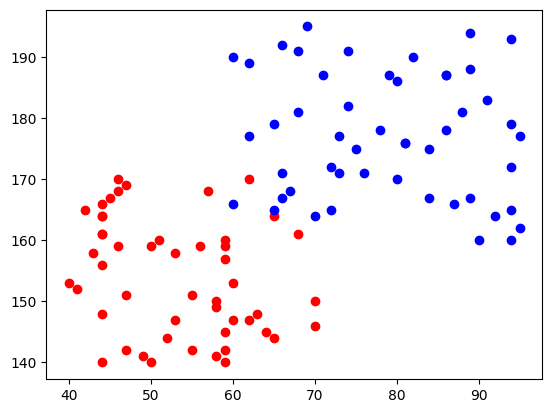

In [7]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color = 'r')
plt.plot([male[0] for male in data[1::2]],
         [male[1] for male in data[1::2]], 'o', color = 'b')
plt.show()

# 2. 군집화 로직

In [24]:
# 초기 랜덤 지정 2 point
random_points = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_points

[[80, 180], [55, 144]]

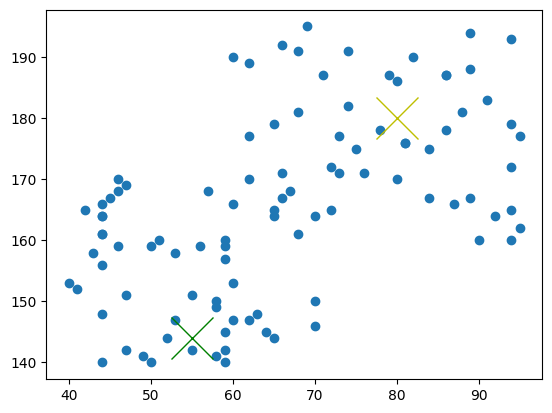

In [25]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_points[0][0],random_points[0][1], 'x', markersize=30, color='y')
plt.plot(random_points[1][0],random_points[1][1], 'x', markersize=30, color='g')
plt.show()

In [26]:
# 두 점 거리를 return하는 함수
def dist(a, b):
    return np.sqrt((a[0]-b[0])**2+(a[1]-b[1])**2)

In [51]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)으로 분류 - *1
group0=[]
group1=[]
for d in data:
    if dist(random_points[0], d) < dist(random_points[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(48, 52)

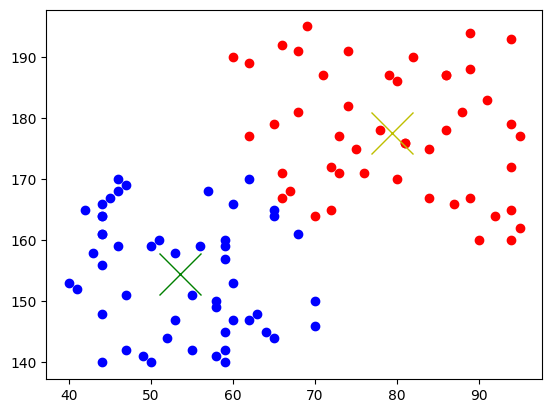

In [52]:
# group0, group1
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='r')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='b')
plt.plot(random_points[0][0],random_points[0][1], 'x', markersize=30, color='y')
plt.plot(random_points[1][0],random_points[1][1], 'x', markersize=30, color='g')

In [53]:
# group0과 group1 중심점으로 기준점을 이동 - *2
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_points[1] = [group1_meanX, group1_meanY]

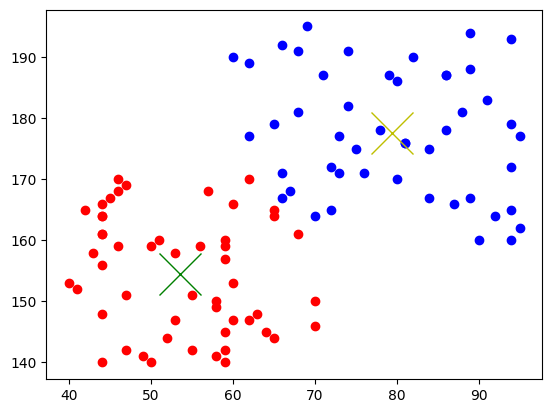

In [55]:
# group0, group1
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='y')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='g')
plt.show()

# 3. 군집화 전체 코드
- *1 ~ *2 반복<br>

* for 문
    - 2개의 랜덤 포인트 기준 각각 그룹화
    - 랜덤 포인트의 좌표를 각 그룹의 중심점으로 이동
    - 출력 및 시각화

초기 지점 :  [[53, 194], [86, 146]]
1번째 지점 :  [[62.0, 174.89], [69.07, 158.21]]
2번째 지점 :  [[67.78, 176.8], [64.14, 154.3]]
3번째 지점 :  [[76.92, 177.88], [55.43, 153.71]]
4번째 지점 :  [[79.04, 177.41], [53.39, 154.16]]
5번째 지점 :  [[79.4, 177.56], [53.56, 154.46]]
6번째 지점 :  [[79.4, 177.56], [53.56, 154.46]]
7번째 지점 :  [[79.4, 177.56], [53.56, 154.46]]
8번째 지점 :  [[79.4, 177.56], [53.56, 154.46]]
9번째 지점 :  [[79.4, 177.56], [53.56, 154.46]]


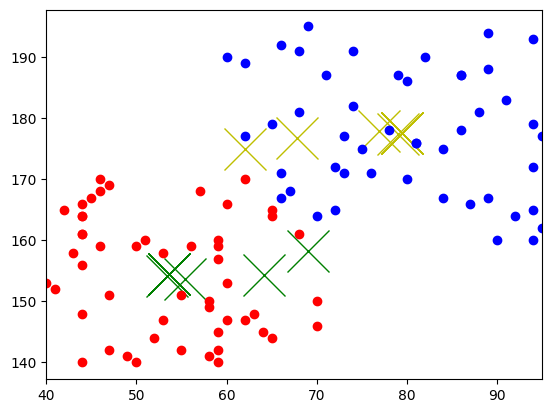

In [97]:
random_points = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
print('초기 지점 : ', random_points)

for i in range(1, 10):
    group0=[]
    group1=[]
    for d in data:
        if dist(random_points[0], d) < dist(random_points[1], d):
            group0.append(d)
        else:
            group1.append(d)

    group0_meanX = np.mean([d[0] for d in group0]).round(2)
    group0_meanY = np.mean([d[1] for d in group0]).round(2)
    random_points[0] = [group0_meanX, group0_meanY]
    
    group1_meanX = np.mean([d[0] for d in group1]).round(2)
    group1_meanY = np.mean([d[1] for d in group1]).round(2)
    random_points[1] = [group1_meanX, group1_meanY]
    print(f'{i}번째 지점 : ', random_points)
    plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='y')
    plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='g')

plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.xlim([40, 95])
plt.show()

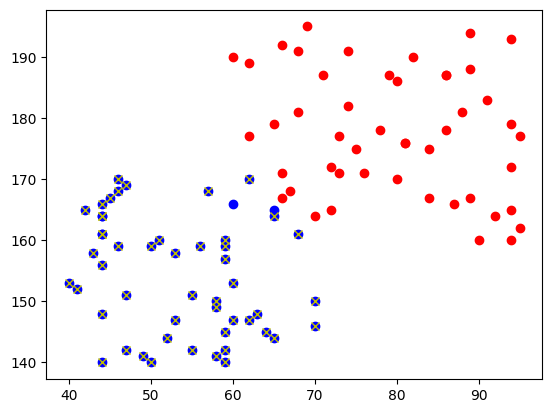

In [101]:
plt.plot([g[0] for g in group0],
         [g[1] for g in group0], 'o', color='r')
plt.plot([g[0] for g in group1],
         [g[1] for g in group1], 'o', color='b')
plt.plot([female[0] for female in data[::2]], [female[1] for female in data[::2]], 'x', color='y')

# 4. API(sklearn)를 이용한 군집화
- sklearn : 머신러닝 pkg
    * 예측 모델 (지도학습 : 회귀 분석, 분류 분석)
        - 정답(Label)이 있는 데이터 학습
        - 주요 메서드 : 학습 `fit(X, y)`, 예측 `predict(X)`
    * 군집 모델 (비지도학습 : 군집화)
        - 정답(Label)이 없는 데이터의 유사성 기반 그룹화
        - 주요 메서드 : 학습 `fit(X)`, 분류 `predict(X)`, 학습 및 분류 `fit_predict(X)`
    * 변환 모델 (데이터 변환)
        - 데이터 전처리 및 차원 축소 (Scalers, PCA 등)
        - 주요 메서드 : 학습 `fit(X)`, 변환 `transform(X)`, 학습 및 변환 `fit_transform(X)`

In [ ]:
# # CPU 사용 환경 설정 ; 사용 코어 수 조정
# import os
# os.environ['OMP_NUM_THREADS'] = '1'

In [103]:
from sklearn.cluster import KMeans

data = np.array(data) # 머신러닝 모델은 넘파이 배열로 학습함 (메모리 연속성으로 인한 고속 연산, 반복문 없이 벡터화 연산 가능, 타입 고정 등)

model = KMeans(
    n_clusters=2,     # 생성할 군집(클러스터)의 개수
    init='random',    # 중심점(Centroid) 초기값 위치 지정 방식 (기본값은 'k-means++')
    n_init=10,        # 서로 다른 초기 중심점으로 전체 알고리즘을 반복 실행할 횟수
    random_state=7    # 실행할 때마다 동일한 결과를 얻기 위한 난수 고정 값 (Seed)
)

model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [105]:
# 군집화 코드를 사용한 각 그룹의 중심점 = [79.4, 177.56], [53.56, 154.46]
# K-Means 학습 결과로 구해진 각 그룹의 중심점 좌표
model.cluster_centers_.round(2)

array([[ 79.4 , 177.56],
       [ 53.56, 154.46]])

In [106]:
# 나눠진 데이터의 그룹 인덱스(0, 1)
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0])

In [109]:
group1 = data[model.labels_==1]
group0 = data[model.labels_==0]

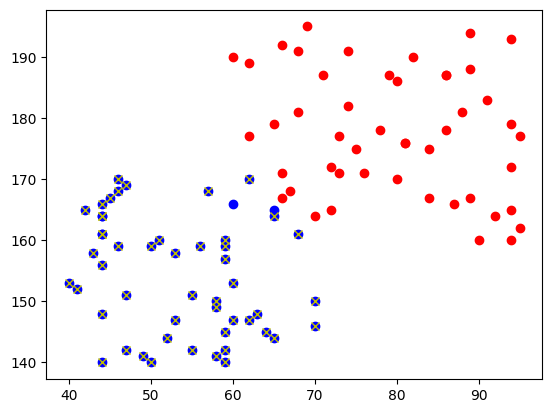

In [110]:
plt.plot([g[0] for g in group0],
         [g[1] for g in group0], 'o', color='r')
plt.plot([g[0] for g in group1],
         [g[1] for g in group1], 'o', color='b')
plt.plot([female[0] for female in data[::2]], [female[1] for female in data[::2]], 'x', color='y')